
  MODULE 4A: LINEAR REGRESSION

───────────────────────────────────────────────────────
  DATASET: 11-node
───────────────────────────────────────────────────────
  Loading: fleet_trips_11nodes.csv
  Rows: 3,000  |  Features: 6  |  Target mean: 51.3 mins
  Train rows: 2,400  |  Test rows: 600
  Training Linear Regression...
  Training complete.

  ─────────────────────────────────────────────
  EVALUATION RESULTS — 11-node
  ─────────────────────────────────────────────
  MAE  (avg mins off)     : 12.606 mins
  RMSE (penalised error)  : 17.246 mins
  R²   (variance explained): 0.8120
  CV R² (5-fold mean±std) : 0.7972 ± 0.0185
  ─────────────────────────────────────────────
  Plot saved: module4_outputs/linear_regression_11-node.png


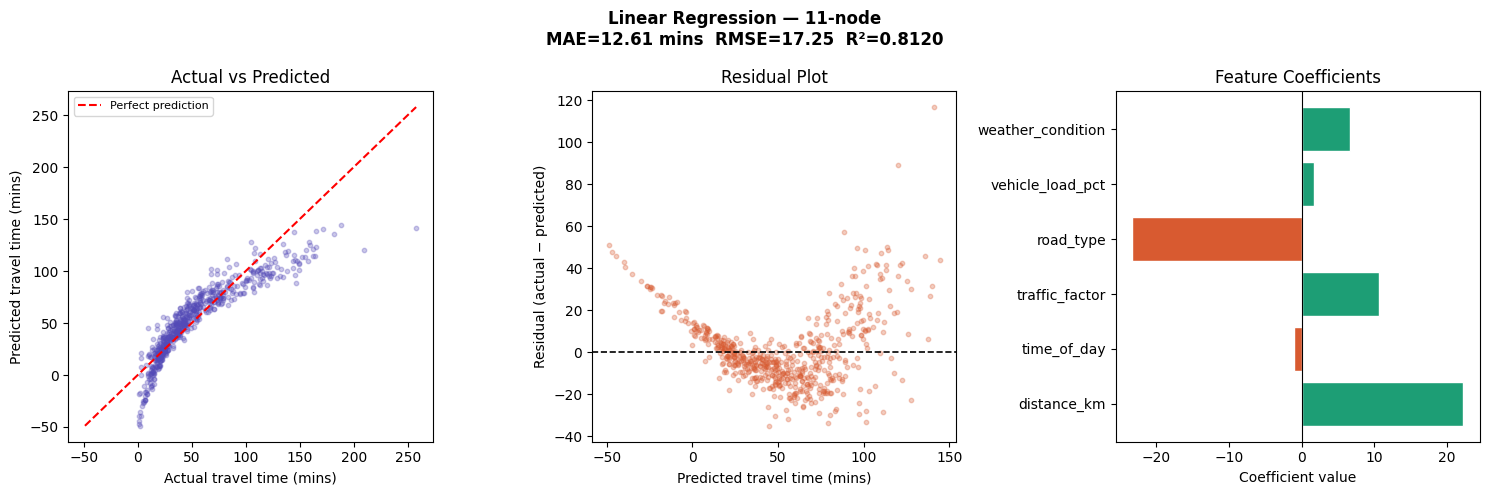

  Model saved: module4_outputs/linear_regression_11-node.pkl

  SUMMARY — LINEAR REGRESSION ACROSS PROBLEM SIZES
  Dataset           MAE     RMSE       R²
  ────────────────────────────────────────
  11-node        12.606   17.246   0.8120



In [1]:
# ============================================================
# MODULE 4A: LINEAR REGRESSION — Travel Time Prediction
# Thesis: Predictive Optimization for Fleet Routing
# ============================================================
# WHAT IS LINEAR REGRESSION?
#   The simplest ML model. It draws a straight line through
#   your data and uses that line to make predictions.
#   Formula: travel_time = (w1 × distance) + (w2 × traffic)
#            + (w3 × weather) + ... + constant
#   It learns the best weights (w1, w2, ...) from your data.
#
# WHY INCLUDE IT IN YOUR THESIS?
#   It acts as a baseline. If Random Forest and XGBoost
#   cannot beat Linear Regression, something is wrong.
#   It also gives you a clean model comparison story:
#   simple → medium → complex.
#
# LIMITATION:
#   Assumes all relationships are straight lines.
#   Real traffic patterns are non-linear (rush hour spikes),
#   so Linear Regression is expected to underperform here.
#   That is actually useful — it motivates the other models.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.linear_model    import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline


# ============================================================
# CONFIGURATION
# ============================================================

DATASET_FILES = {
    "11-node": "fleet_trips_11nodes.csv",
    #"25-node": "fleet_trips_25nodes.csv",
    #"50-node": "fleet_trips_50nodes.csv",
}

# These are the columns we feed into the model (inputs)
FEATURE_COLS = [
    "distance_km",
    "time_of_day",
    "traffic_factor",
    "road_type",
    "vehicle_load_pct",
    "weather_condition",
]

# This is what the model learns to predict (output)
TARGET_COL = "travel_time_mins"

RANDOM_SEED  = 42
TEST_SIZE    = 0.20   # 80% train, 20% test
OUTPUT_DIR   = "module4_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# STEP 1: LOAD DATA
# ============================================================

def load_data(filepath):
    """
    Reads the CSV generated in Module 3.
    Separates features (X) from target (y).

    X = the inputs the model uses to make predictions
    y = the correct answer the model tries to learn
    """
    print(f"  Loading: {filepath}")
    df = pd.read_csv(filepath)

    # Confirm expected columns exist
    missing = [c for c in FEATURE_COLS + [TARGET_COL] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    X = df[FEATURE_COLS]
    y = df[TARGET_COL]

    print(f"  Rows: {len(df):,}  |  Features: {len(FEATURE_COLS)}  "
          f"|  Target mean: {y.mean():.1f} mins")
    return X, y



# ============================================================
# STEP 2: PREPROCESS DATA
# ============================================================

def preprocess(X, y, label):
    """
    Cleans and validates the dataset before training.
    Even with synthetic data, always show you checked.
    This demonstrates ML rigour in your thesis.
    """
    print(f"\n  Preprocessing — {label}")
    original_len = len(X)

    # --- Task 1: Check for missing values ---
    missing = X.isnull().sum()
    target_missing = y.isnull().sum()
    if missing.any() or target_missing > 0:
        print(f"  WARNING: Missing values found:")
        print(missing[missing > 0])
        # Drop rows with any missing value
        mask = X.notnull().all(axis=1) & y.notnull()
        X, y = X[mask], y[mask]
        print(f"  Dropped {original_len - len(X)} rows with missing values")
    else:
        print(f"  Missing values  : none found ✓")

    # --- Task 2: Detect and remove outliers (IQR method) ---
    # IQR = Interquartile Range (distance between 25th and 75th percentile)
    # Values beyond 3×IQR from the median are considered extreme outliers
    Q1  = y.quantile(0.25)
    Q3  = y.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    mask  = (y >= lower) & (y <= upper)
    removed = (~mask).sum()

    if removed > 0:
        print(f"  Outliers removed: {removed} rows "
              f"(travel_time outside {lower:.1f}–{upper:.1f} mins)")
        X, y = X[mask], y[mask]
    else:
        print(f"  Outliers        : none removed ✓")

    # --- Task 3: Confirm encoding (already done in Module 3) ---
    print(f"  Categorical enc : road_type_enc, weather_enc ✓")

    # --- Task 4: Scaling note ---
    # Linear Regression: StandardScaler applied inside pipeline
    # Random Forest + XGBoost: not required (tree-based models)
    print(f"  Feature scaling : handled per model type ✓")

    # --- Summary report ---
    print(f"  Rows before     : {original_len:,}")
    print(f"  Rows after      : {len(X):,}")
    print(f"  Target range    : {y.min():.1f} – {y.max():.1f} mins")
    print(f"  Target mean     : {y.mean():.2f} mins  "
          f"std: {y.std():.2f} mins")

    return X.reset_index(drop=True), y.reset_index(drop=True)



# ============================================================
# STEP 3: SPLIT DATA
# ============================================================

def split_data(X, y):
    """
    Splits data into training set and test set.

    Training set (80%): model learns from this
    Test set    (20%): model is evaluated on this
                       (it has NEVER seen these rows)

    Why split? If you test on data the model trained on,
    results look artificially good — this is called overfitting.
    A held-out test set gives an honest performance estimate.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED
    )
    print(f"  Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
    return X_train, X_test, y_train, y_test


# ============================================================
# STEP 4: BUILD AND TRAIN MODEL
# ============================================================

def build_and_train(X_train, y_train):
    """
    Builds a Pipeline: StandardScaler → LinearRegression

    StandardScaler:
        Rescales all features to the same range before training.
        Without this, distance_km (large numbers) would dominate
        over weather_enc (small numbers 0-3). Scaling levels the
        playing field so the model treats all features fairly.

    LinearRegression:
        Finds the best-fit line through the training data by
        minimizing the sum of squared prediction errors.
        This is called Ordinary Least Squares (OLS).
    """
    pipeline = Pipeline([
        ("scaler", StandardScaler()),       # normalize features
        ("model",  LinearRegression()),     # fit the line
    ])

    print("  Training Linear Regression...")
    pipeline.fit(X_train, y_train)
    print("  Training complete.")
    return pipeline


# ============================================================
# STEP 5: EVALUATE MODEL
# ============================================================

def evaluate(pipeline, X_train, X_test, y_train, y_test, label):
    """
    Measures how well the model predicts on unseen test data.

    Metrics explained in plain English:
    -------------------------------------------------------
    MAE  (Mean Absolute Error):
         On average, how many minutes off is the prediction?
         e.g. MAE=4.2 means predictions are ±4.2 mins off
         LOWER IS BETTER

    RMSE (Root Mean Squared Error):
         Like MAE but punishes big errors harder.
         Useful for catching cases where model is very wrong.
         LOWER IS BETTER

    R²   (R-squared / Coefficient of Determination):
         What % of travel time variation does the model explain?
         R²=0.85 means model explains 85% of the variance.
         R²=1.0 is perfect. R²=0.0 means model is useless.
         HIGHER IS BETTER

    Cross-validation (CV):
         Splits training data into 5 folds, trains/tests 5 times.
         Gives a more reliable performance estimate than one split.
    """
    y_pred = pipeline.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # Cross-validation on training set
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring="r2"
    )

    print(f"\n  {'─'*45}")
    print(f"  EVALUATION RESULTS — {label}")
    print(f"  {'─'*45}")
    print(f"  MAE  (avg mins off)     : {mae:.3f} mins")
    print(f"  RMSE (penalised error)  : {rmse:.3f} mins")
    print(f"  R²   (variance explained): {r2:.4f}")
    print(f"  CV R² (5-fold mean±std) : "
          f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  {'─'*45}")

    return {
        "label":   label,
        "model":   "Linear Regression",
        "mae":     mae,
        "rmse":    rmse,
        "r2":      r2,
        "cv_mean": cv_scores.mean(),
        "cv_std":  cv_scores.std(),
        "y_test":  y_test,
        "y_pred":  y_pred,
    }


# ============================================================
# STEP 6: VISUALIZE RESULTS
# ============================================================

def visualize(results, label):
    """
    Produces 3 diagnostic plots for your thesis:

    Plot 1 — Actual vs Predicted:
        Points near the diagonal = accurate predictions.
        Scatter away from diagonal = errors.

    Plot 2 — Residuals (prediction errors):
        Residual = actual - predicted
        Should be randomly scattered around zero.
        Patterns in residuals reveal model weaknesses.

    Plot 3 — Feature coefficients:
        Shows which features the model weighted most.
        Larger coefficient = stronger influence on prediction.
    """
    y_test  = results["y_test"]
    y_pred  = results["y_pred"]
    residuals = y_test - y_pred
    safe_label = label.replace(" ", "_").replace("/", "_")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"Linear Regression — {label}\n"
        f"MAE={results['mae']:.2f} mins  "
        f"RMSE={results['rmse']:.2f}  "
        f"R²={results['r2']:.4f}",
        fontsize=12, fontweight="bold"
    )

    # Plot 1: Actual vs Predicted
    ax = axes[0]
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color="#534AB7")
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual travel time (mins)")
    ax.set_ylabel("Predicted travel time (mins)")
    ax.set_title("Actual vs Predicted")
    ax.legend(fontsize=8)

    # Plot 2: Residuals
    ax = axes[1]
    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color="#D85A30")
    ax.axhline(0, color="black", linestyle="--", lw=1.2)
    ax.set_xlabel("Predicted travel time (mins)")
    ax.set_ylabel("Residual (actual − predicted)")
    ax.set_title("Residual Plot")

    # Plot 3: Feature coefficients
    ax = axes[2]
    coefs = results.get("coefs", None)
    if coefs is not None:
        colors = ["#1D9E75" if c > 0 else "#D85A30" for c in coefs]
        ax.barh(FEATURE_COLS, coefs, color=colors, edgecolor="white")
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title("Feature Coefficients")
        ax.set_xlabel("Coefficient value")

    plt.tight_layout()
    path = os.path.join(
        OUTPUT_DIR,
        f"linear_regression_{safe_label}.png"
    )
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Plot saved: {path}")
    plt.show()


# ============================================================
# STEP 7: SAVE MODEL
# ============================================================

def save_model(pipeline, label):
    """
    Saves the trained model to disk using joblib.
    In Module 5 you load this file to generate predictions
    without re-training from scratch every time.
    """
    safe_label = label.replace(" ", "_").replace("/", "_")
    path = os.path.join(OUTPUT_DIR, f"linear_regression_{safe_label}.pkl")
    joblib.dump(pipeline, path)
    print(f"  Model saved: {path}")
    return path


# ============================================================
# MAIN
# ============================================================

def main():
    print("\n" + "="*55)
    print("  MODULE 4A: LINEAR REGRESSION")
    print("="*55)

    all_results = []

    for label, filepath in DATASET_FILES.items():
        if not os.path.exists(filepath):
            print(f"\n  WARNING: {filepath} not found — skipping.")
            continue

        print(f"\n{'─'*55}")
        print(f"  DATASET: {label}")
        print(f"{'─'*55}")

        # Step 1: Load
        X, y = load_data(filepath)

        # Step 2: Split
        X_train, X_test, y_train, y_test = split_data(X, y)

        # Step 3: Train
        pipeline = build_and_train(X_train, y_train)

        # Step 4: Evaluate
        results = evaluate(pipeline, X_train, X_test,
                           y_train, y_test, label)

        # Extract coefficients for visualization
        scaler = pipeline.named_steps["scaler"]
        model  = pipeline.named_steps["model"]
        results["coefs"] = model.coef_

        # Step 5: Visualize
        visualize(results, label)

        # Step 6: Save
        save_model(pipeline, label)

        all_results.append(results)

    # Summary table
    print("\n" + "="*55)
    print("  SUMMARY — LINEAR REGRESSION ACROSS PROBLEM SIZES")
    print("="*55)
    print(f"  {'Dataset':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
    print(f"  {'─'*40}")
    for r in all_results:
        print(f"  {r['label']:<12} "
              f"{r['mae']:>8.3f} "
              f"{r['rmse']:>8.3f} "
              f"{r['r2']:>8.4f}")
    print()


if __name__ == "__main__":
    main()
